# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

<span style="color:blue">**UNDERSTAND THE OBJECTIVE FIRST**</span>

Worldwide, used car sales is a major business occupuation due to its ability to provide affordable transportation to millions of citizens.

Though there is no one-size-fits-all solution as location , region , country , avaiability of public mode of transportation , purpose of owning a car etc and affordability based on demographics also play a part, this exercise makes an effort to understand the fundamental principles of Machine learning algorithm,, specifically LR techniques (Linear and Multiple Linear , Ridge ,Lasso and Elastic Net regression models) in order to price cars based on available features and derived features with additional application of domain knowledge in this field.

Furthermore, since the size of the dataset is huge (400K plus), in order to avoid the model from memorizing the relationships between independent and target variable (price), L1 and L2 regularization and subsequent hyperparamter tuning have been relied upon for creating the optimum model.

During the course of implementing this data mining problem , we would have to constantly refine our solution by not only going back to refine data as needed and repeated remodelling but also by enriching our business understanding from evaluation step.

Finally a summart report would be provided to the intended audience namely used car dealers or franchises who would restructure their inventory accordingly to boost sales.

In [ ]:
# All of the imports needed for the exercise consolidated in the beginning .
#Standard imports
import pandas as pd
import numpy as np
import io

#scikit-learn libs
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
from sklearn.preprocessing import StandardScaler , OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector, make_column_transformer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import Ridge, Lasso, LinearRegression, ElasticNet
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Install category_encoders if not already present
!pip install category_encoders
# Import category_encoders for TargetEncoder
import category_encoders as ce

# Plotting libs
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

#ignore warnings
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 8.9 MB/s eta 0:00:00


**Loading the Data**



In [ ]:
df = pd.read_csv("/content/sample_data/vehicles.csv")
df.shape

(77167, 18)

# Data Dictionary

*  **price - Our target variable**
*  manufacturer - company manufacturing the brand
*  model - model of the specific make of the car
*  year- year of manufacturing the car or bought by 1st owner
*  transmission - whether manual or automatic gear  
*  drive - whether all wheel drive or 2 wheel drive (Front or rear)
*  state - place where car is registered/ manufactured
*  region- region within the state
*  condition - good or bad (ordinal feature , might need encoding )
*  cylinders- specific to the combustion engine , applicable for petrol and diesel cars only
*   size- such as small , medium , SUV- large , coupe , sedan -medium like that *(might need encoding )
*   fuel- whether runs on gasoline or  diesel , electric (encoding needed)
*   title_status - in which form is the vehicle , it is clean , or rebuilt etc .
* paint_color - car color hardly plays any role in prediction
* odometer- the mileage of the car, how many miles / kms it has driven
* id , VIN - identifiers which do not play any role in predictive algorithms (should be dropped for model building)
* type- utility of the vehicle such as pick up or the structure such as sedan or coupe etc

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

Identify numeric and categorical features , also commenting whether we can do any data cleaning or transform into numerical without needing encoder always.

**Data Preprocessing**

Data Cleaning - Broadly, we will follow the following principle .
1. Any cleaning based on domain knowledge and hence identifying outliers would be done pre train_test_split
2. Any data preprocessing including data cleaning based on statistical properties would be done after train test split to avoid data leakage.





**Following CRISP -DM model**
We would first understand the data, describe the statistical properties , observe the categorical and numerical columns (features), define the features for understability .

We will also inspect the quality of the data , null values and any transformations needed.



In [ ]:
# Describe the categorical features
df.describe(include="object")

,region,manufacturer,model,condition,cylinders,fuel,title_status,transmission,VIN,drive,size,type,paint_color,state
count,426880,409234,421603,252776,249202,423867,418638,424324,265838,296313,120519,334022,296677,426880
unique,404,42,29649,6,8,5,6,3,118246,3,4,13,12,51
top,columbus,ford,f-150,good,6 cylinders,gas,clean,automatic,1FMJU1JT1HEA52352,4wd,full-size,sedan,white,ca
freq,3608,70985,8009,121456,94169,356209,405117,336524,261,131904,63465,87056,79285,50614


In [ ]:
# initial random inspection as first few records were NaN for majority of columns in the dataset
df.iloc[150000:150002]

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
150000,7303124206,bloomington,38590,2019.0,ram,1500 crew cab big horn,good,6 cylinders,gas,28556.0,clean,other,1C6RRFFGXKN695394,4wd,NaN,pickup,white,in
150001,7303087652,bloomington,43990,2019.0,ram,1500 crew cab big horn,good,8 cylinders,gas,17352.0,clean,other,1C6SRFFT7KN755503,4wd,NaN,pickup,black,in


In [ ]:
df.describe().apply(lambda s: s.apply('{0:.5f}'.format))# Print numerical values , maximum price is abnormal and points to data outliers or errors.

,id,price,year,odometer
count,426880.00000,426880.00000,425675.00000,422480.00000
mean,7311486634.22433,75199.03319,2011.23519,98043.33144
std,4473170.41256,12182282.17360,9.45212,213881.50080
min,7207408119.00000,0.00000,1900.00000,0.00000
25%,7308143339.25000,5900.00000,2008.00000,37704.00000
50%,7312620821.00000,13950.00000,2013.00000,85548.00000
75%,7315253543.50000,26485.75000,2017.00000,133542.50000
max,7317101084.00000,3736928711.00000,2022.00000,10000000.00000


In [ ]:
#  Display information about columns
df.info() # too many null columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [ ]:
# Inpsect null values in the dataset , aim to identify null features adding no usability for prediction such as identifiers .
#calculate percentage of missing values for each variable , sorting descending on pct.
Total=df.isnull().sum()
Percent = (df.isnull().sum()*100/df.isnull().count()).sort_values(ascending=False)
# concat the 'Total' and 'Percent' columns using 'concat' function
# pass a list of column names in parameter 'keys'

missing_data = pd.concat([Total, Percent], axis = 1, keys = ['Total', 'Percentage of Missing Values'])
missing_data.sort_values(by='Total', ascending=False)


,Total,Percentage of Missing Values
size,56176,72.797958
cylinders,30808,39.923802
condition,28901,37.452538
VIN,27616,35.787318
paint_color,23903,30.975676
drive,23402,30.326435
type,15366,19.912657
manufacturer,3228,4.183135
title_status,2036,2.638434
odometer,1328,1.720943


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [ ]:
# DATA CLEANING
#1. remove id and VIN as they dont add any value to model for predictions .
#2. size is missing from 71% , the model and make already indicate what would be the size , hence fair to drop it as it is redundant and would introduce noise and multicollinearity .
#3  similarly , type feature can be dropped as well because make and model also indicate the type , any dealer or buyer knows what they're buying .
df = df.drop(columns={"id","VIN","size","type"})
df.columns

Index(['region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission',
       'drive', 'paint_color', 'state'],
      dtype='object')

In [ ]:
# Remove duplicates
# check for duplicate
#duplicate_rows = df[df.duplicated()]
df= df.drop_duplicates()
df.shape

(65700, 14)

In [ ]:
# In order to eliminate bizzare values , remove the top 0.001% highest priced cars that are certainly erroneous , without loss of generality.
price_upper_bound = np.quantile(df['price'], 0.999)
df = df[df['price'] <= price_upper_bound]
df['price'].max() # ~ 120,000 which is reasonable enough to build a simple model. There would be some very expensive cars outliers, but this is an approximation. Only 367 further cars removed .

129500

In [ ]:
# even then  lots of values if sorted in ascending can be seen to be 0s and 1 ,
#points to lots of errors still exist, a car price should be at least around 1500 to be considered a reasonable sale in a decent model.
df= df[df['price']>1000]
df['price'].sort_values(ascending=False).head(2)


,price
44186,129500
42105,129500


#Plot the price as Target variable

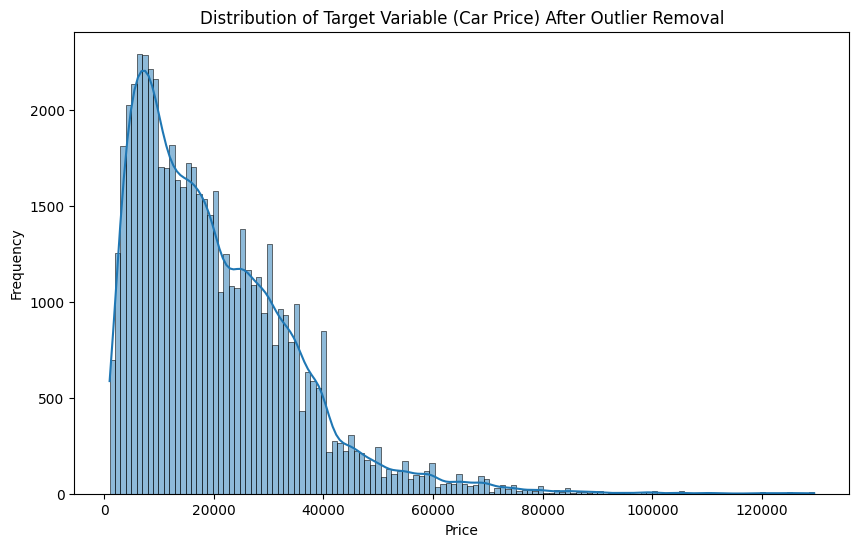

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of Target Variable (Car Price) After Outlier Removal')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

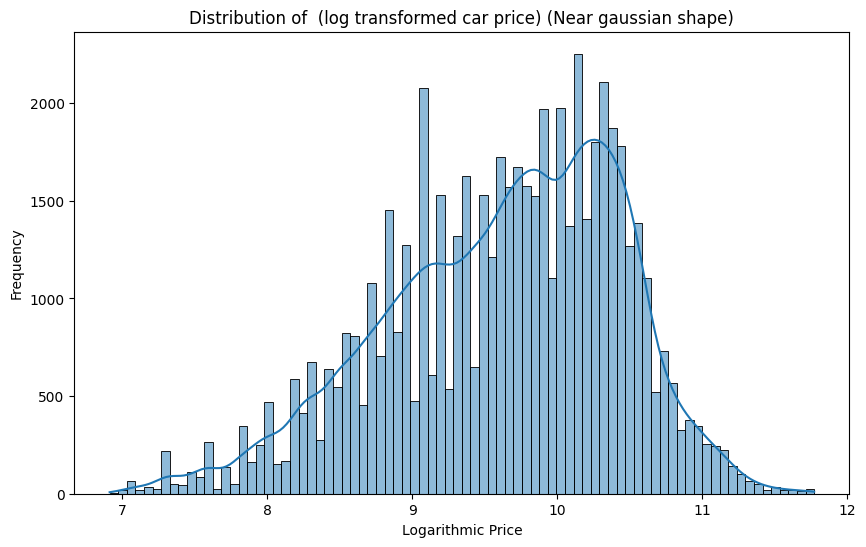

In [ ]:
# During EDA , the Targetvalue rice plot looked skewed to left,so we typically take a log_price to normalize the distribution and mitigate impact of outliers.
df['log_price']= np.log(df['price'])
df.drop(columns={'price'}, inplace=True)
plt.figure(figsize=(10, 6))
sns.histplot(df['log_price'], kde=True)
plt.title('Distribution of  (log transformed car price) (Near gaussian shape)')
plt.xlabel('Logarithmic Price')
plt.ylabel('Frequency')
plt.show()
# We can see that the distribution is near normalized now, except some outliers.

# Plot of individual features such as odometer, age, manufacturer,cylinders and target variable log_price

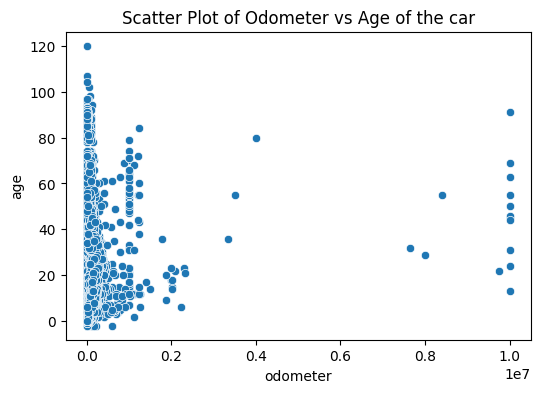

In [ ]:
# Note - the kaggle dataset is actually from 2020.
# 'year' can be transformed into Age for a better prediction model and often more interpretable .
df['age']= 2020-df['year']
plt.figure(figsize=(6,4))
#Plot the relation between odometer and age
sns.scatterplot(data=df, x ='odometer',y= 'age')
plt.title('Scatter Plot of Odometer vs Age of the car')
plt.show()

# drop the year and price columns
df = df.drop(columns={'year'})


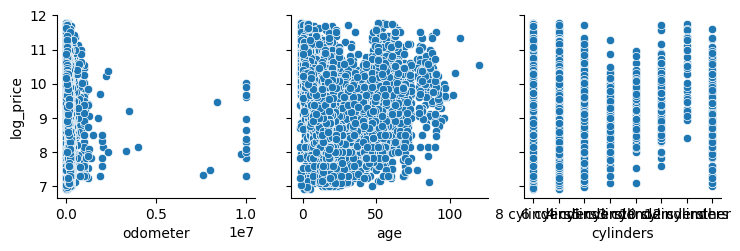

In [ ]:
sns.pairplot(df, x_vars=['odometer','age','cylinders'], y_vars='log_price')

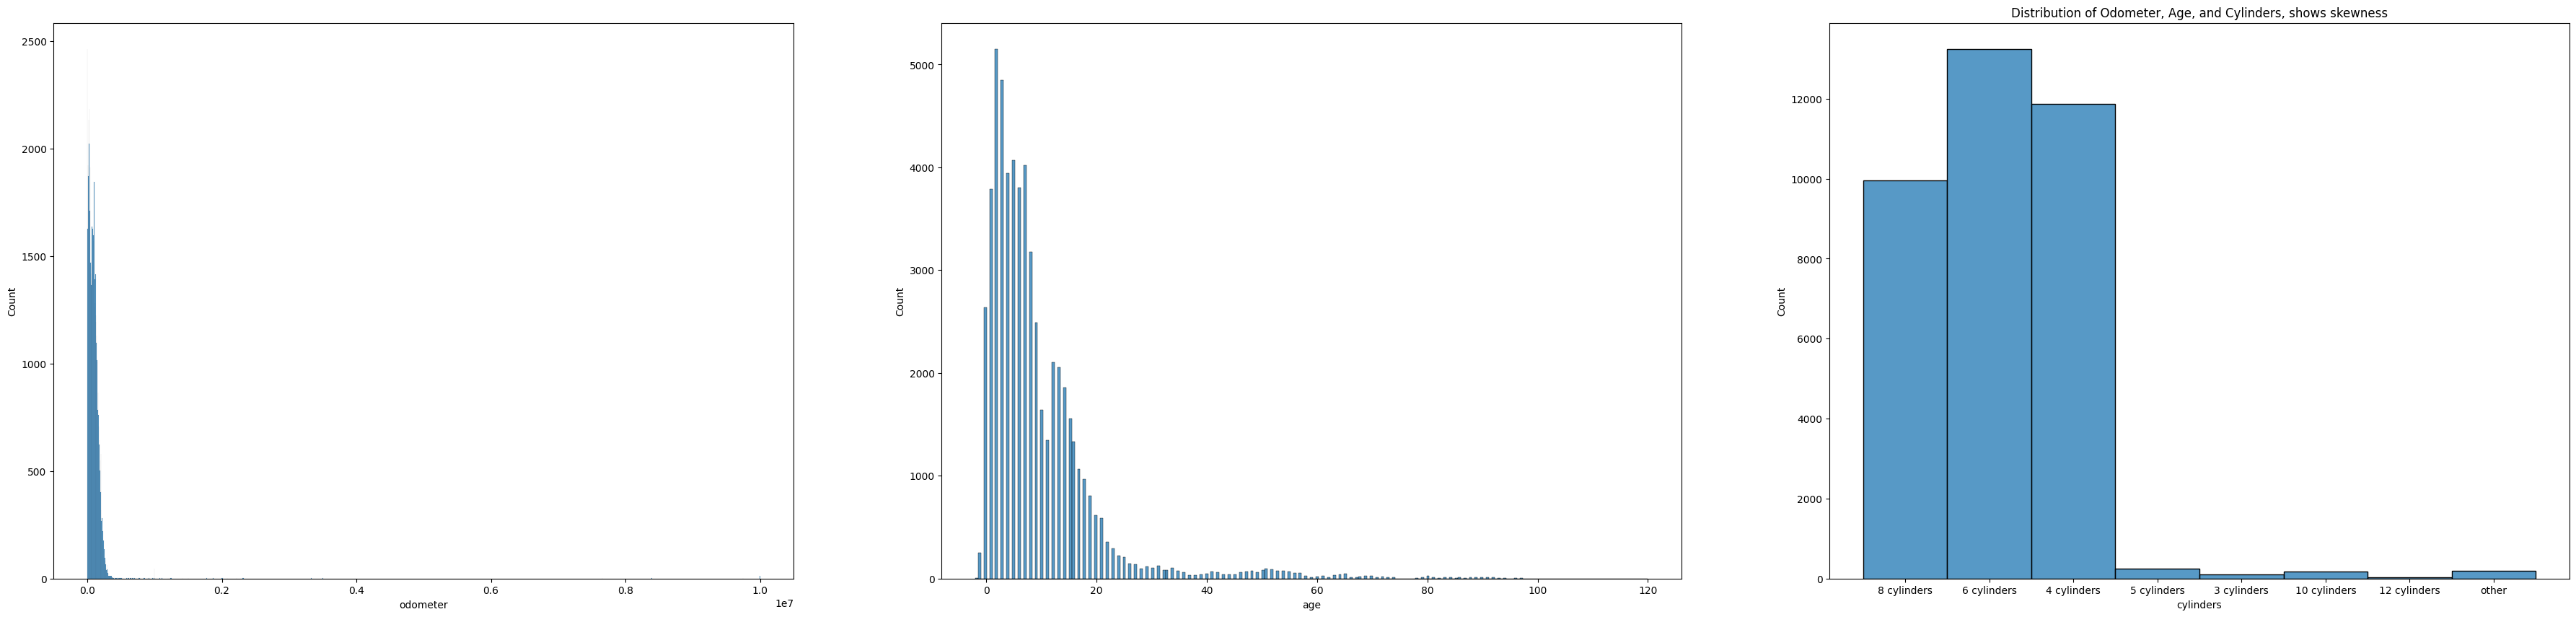

In [ ]:
#Plot the distribution of odometer, age and cylinders in subplots
fig, axs = plt.subplots(1, 3, figsize=(45,10))
sns.histplot(df['odometer'], ax=axs[0])
sns.histplot(df['age'], ax=axs[1])
sns.histplot(df['cylinders'], ax=axs[2])
plt.title('Distribution of Odometer, Age, and Cylinders, shows skewness')
plt.show()

In [ ]:
# Now,  time to take care of nulls, first print unique values as most columns are  categorical in nature and would need encoding(s) later .
#df.isnull().sum()
print("title_status",df['title_status'].unique())# fill with mode, clear majority of "clean" class
print("cylinders",df['cylinders'].unique())# possibly fill with "others"  # remove cylinders for numerical value # categorical
print("drive",df['drive'].unique())# [nan 'rwd' '4wd' 'fwd'] - # categorical eventually
print("transmission",df['transmission'].unique()) #transmission [nan 'other' 'automatic' 'manual']  # categorical
print("fuel",df['fuel'].unique()) #  categorical
print("paint_color",df['paint_color'].unique()) # categorical
print("manufacturer",df['manufacturer'].unique()) # categorical  (43)
print("model",df['model'].unique()) #  categorical but 30K different ones, need specialized encoding, will see later
print("condition",df['condition'].unique())  #  categorical

title_status [nan 'clean' 'rebuilt' 'lien' 'salvage' 'missing' 'parts only']
cylinders [nan '8 cylinders' '6 cylinders' '4 cylinders' '5 cylinders' '3 cylinders'
 '10 cylinders' '12 cylinders' 'other']
drive [nan 'rwd' '4wd' 'fwd']
transmission [nan 'other' 'automatic' 'manual']
fuel [nan 'gas' 'other' 'diesel' 'hybrid' 'electric']
paint_color [nan 'white' 'blue' 'red' 'black' 'silver' 'grey' 'brown' 'yellow'
 'orange' 'green' 'custom' 'purple']
manufacturer [nan 'gmc' 'chevrolet' 'toyota' 'ford' 'jeep' 'nissan' 'ram' 'mazda'
 'cadillac' 'honda' 'dodge' 'lexus' 'jaguar' 'buick' 'chrysler' 'volvo'
 'audi' 'infiniti' 'lincoln' 'alfa-romeo' 'subaru' 'acura' 'hyundai'
 'mercedes-benz' 'bmw' 'mitsubishi' 'volkswagen' 'porsche' 'kia' 'rover'
 'ferrari' 'mini' 'pontiac' 'fiat' 'tesla' 'mercury' 'saturn'
 'harley-davidson' 'datsun' 'aston-martin' 'land rover']
model [nan 'sierra 1500 crew cab slt' 'silverado 1500' ... 'cherooke laredo'
 'chevorlet cruze' 'eldorado convertible']
condition [nan 

In [ ]:
# Inpsect null values in the dataset , aim to identify null features adding no usability for prediction such as identifiers .
#calculate percentage of missing values for each variable , sorting descending on pct.
Total=df.isnull().sum()
Percent = (df.isnull().sum()*100/df.isnull().count()).sort_values(ascending=False)
# concat the 'Total' and 'Percent' columns using 'concat' function
# pass a list of column names in parameter 'keys'
# 'axis = 1' concats along the columns
missing_data = pd.concat([Total, Percent], axis = 1, keys = ['Total', 'Percentage of Missing Values'])
missing_data.sort_values(by='Total', ascending=False)

,Total,Percentage of Missing Values
cylinders,22554,38.630447
condition,18450,31.601124
drive,17445,29.879762
paint_color,15857,27.159838
manufacturer,2489,4.263154
title_status,1248,2.137572
model,731,1.252055
odometer,681,1.166415
age,246,0.421348
fuel,222,0.380241


**New category vs Imputation(Analyzing)**

This part takes care of critical decision whether to create a new class for categorical columns or impute(after train_test_split) with mode or median for (categorical and numerical columns).

From the above tables (unique counts and nulls for each feature), it is clear that *cylinder, drive and paint* have 30-40% missing data, removing nulls would impact the dataset distribution hence we would create a category called 'others' due to no clear majority of the representing classes for each of these features .This is ok to be done before split and is not data leakage as we are not using any statistical decision here.

Other decisions taken are  -
For all other *categorical columns* ,fill with mode after tt_split .
For *numerical columns* odometer and age, fill with median.

**We will perform the Imputations as part of modelling during pipleine building.**

In [ ]:
df['model'].value_counts().sort_values(ascending=False) ## close to 30K different models

,count
model,
f-150,782
silverado 1500,541
accord,484
civic,458
tacoma,453
...,...
hona civic hybrid,1
monteri,1
7-series 740li,1


**High cardinality data**

*   US states
*   States regions
*   Models




In [ ]:
# Unique states and regions
len(df['state'].unique())#  51 us states - keep
len(df['region'].unique())#  404 regions
# would drop regions , too much granularity will cause overfitting and complex model increase computations
df = df.drop(columns={"region"})

In [ ]:
# Handle model null values # only
df['model'].isnull().sum()# only np.int64(3970)
# hence can be removed those rows
df = df.dropna(subset=['model'])
df['model'].isnull().sum() # returns 0

# Handle manufacturer null values # does not make sense to impute because make is the brand of the car and most important feature hence drop these null rows
df['manufacturer'].isnull().sum()# only np.int64(13428)
df = df.dropna(subset=['manufacturer'])
df['manufacturer'].isnull().sum()


np.int64(0)

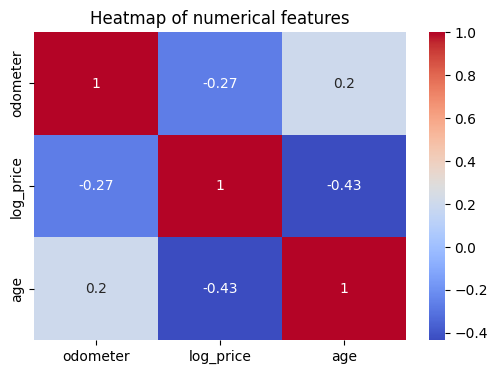

In [ ]:
# Plot heatmap of numerical columns to see if there is some multicollinearity
# 1. Select only numerical features
numeric_df = df.select_dtypes(include=['number'])

# 2. Compute the correlation matrix
corr_matrix = numeric_df.corr()
plt.figure(figsize=(6, 4))
sns.heatmap(data=corr_matrix, annot=True, cmap='coolwarm')
plt.title("Heatmap of numerical features")
plt.show()
# Not a very high corr in numerical columns which is a good sign - Goes with general understanding with older cars causing lower prices(logarithmic though monotonic) .

In [ ]:
# Transform the cylinder column from string to numeric
df['cylinders']=df['cylinders'].str.split(" ").str[0]
df['cylinders'].isnull().sum() # np.int64(126465)
df['cylinders'].value_counts(ascending=True)# dominated by 6 cylinders

,count
cylinders,
12,15
3,86
other,143
10,163
5,232
8,9273
4,11331
6,12647


In [ ]:
df.isnull().sum()

,0
manufacturer,0
model,0
condition,17308
cylinders,21295
fuel,165
odometer,644
title_status,1152
transmission,157
drive,16142
paint_color,14765


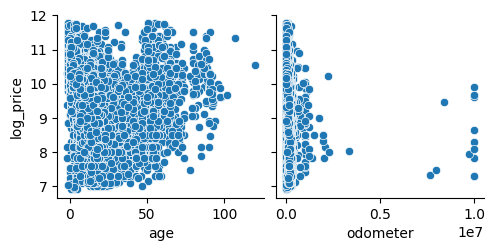

In [ ]:
# Visualize relationships between numeric features and target var log price
sns.pairplot(df, x_vars=['age','odometer'], y_vars='log_price')
plt.show()
# some indication that lower mileage of car (lesser travelled) lead to higher prices.

In [ ]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
print(df.describe())
pd.reset_option('display.float_format')

          odometer  log_price       age
count    54541.000  55185.000 55184.000
mean     92790.149      9.633     8.963
std     164555.143      0.800     9.740
min          0.000      6.914    -2.000
25%      35239.000      9.104     3.000
50%      81206.000      9.741     6.000
75%     130000.000     10.240    12.000
max   10000000.000     11.771   120.000


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [ ]:
# Now split the dataset into X and y before split .
X = df.drop(columns =['log_price'])
y = df['log_price']
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
# Add additional class 'other' for features as disucssed earlier - cylinders, drive and paint
# Following  imputation can be done before split as well , no statistical props used and just a new class other being created as part of the feature
other_imputer_columns=['paint_color','drive','cylinders']
for column in other_imputer_columns:
    df[column].fillna('other', inplace=True)

**Preprocessor Transformation Before model building pipeline**

Due to great variations in data types of features , we would follow the following column transformations , followed by the model pipeline definition.

Preprocessor (ColumnTransformer)

1.Numeric columns:
   Median Imputer
   → optional scaler

2.Categorical columns:
   Mode Imputer
   → One-hot encoding

3. High-cardinality column:
   Mode Imputer
   → Frequency encoding (TargetEncoding)

And then,
**Final Pipeline**
Preprocessor
→ Model


**Build a table of features and define whether numeric and needs scaling or encoding**
categorical - manufacturer,cylinders,fuel,title_status,transmission,drive, paint_color,state, condition

numeric - odometer, age

model of the car - frequency encoding to preserve the distribution






In [ ]:
#Unique models are
print(len(df['model'].value_counts()))#27K models
#I want to reduce cardinality but model is important (since we removed type and size both), hence we will  use frequency encoder during sklearn pipeline.
model_counts= df['model'].value_counts(ascending=False)
#X_train['model'].value_counts()


8557


In [ ]:
categorical_features= ['manufacturer', 'fuel', 'title_status', 'transmission', 'drive', 'paint_color', 'state', 'cylinders', 'condition']
numerical_features = ['odometer','age']
frequency_encoder_features = ['model']

# Find the column in df that does not belong to the below features
df.columns[~df.columns.isin(categorical_features + numerical_features + frequency_encoder_features)] ## Only log_price , all columns taken care of

Index(['log_price'], dtype='object')

In [ ]:
# Define preprocessing for numerical , categorical,  high-cardinal features(model above)
numeric_transformer = Pipeline(steps= [("simple_imputer",SimpleImputer(strategy='median')), ("scaler", StandardScaler())])
categorical_transformer = Pipeline(steps= [("simple_imputer",SimpleImputer(strategy='most_frequent')),("onehotencoder", OneHotEncoder(drop='first',handle_unknown='ignore', sparse_output=False))])

#Added StandardScaler to the frequency_transformer as well for 'model'  column
frequency_transformer = Pipeline(steps= [
    ("simple_imputer",SimpleImputer(strategy='most_frequent')),
    ("frequency_encoder", ce.TargetEncoder(handle_unknown='value', handle_missing='value')),
    ("scaler", StandardScaler())
])

In [ ]:
preprocessor = ColumnTransformer (remainder='passthrough',
    transformers= [
        ("categorical_transformer", categorical_transformer, categorical_features),
        ("numeric_transformer", numeric_transformer, numerical_features),
        ("frequency_transformer", frequency_transformer, frequency_encoder_features)
    ]
)

In [ ]:
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('categorical_transformer',
                                 Pipeline(steps=[('simple_imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['manufacturer', 'fuel', 'title_status',
                                  'transmission', 'drive', 'paint_color',
                                  'state', 'cylinders', 'condition']),
                                ('numeric_transformer',
                                 Pipeline(steps=[('simple_imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['odometer', 'age']),
                                ('frequency_transformer',
                                 Pipeline(steps=[('simple_imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('frequency_encoder',
                                                  TargetEncoder()),
                                                 ('scaler', StandardScaler())]),
                                 ['model'])])

In [ ]:
# As we know that the ohe would drop='first' cateogry hence compiling the list below, as they are missing from the above table and happen to be the first
#category alphabetically value within each of the categorical features.
# Dropped categories for OneHotEncoded features:
#   manufacturer: acura
#   fuel: diesel
#   title_status: clean
#   transmission: automatic
#   drive: 4wd
#   paint_color: black
#   state: ak
#   cylinders: 10
#   condition: excellent

In [ ]:
# Now , create a pipeline for baseline Linear regression
pipeline_linear_model= Pipeline(steps=[("preprocesor",preprocessor),('linear_regression',LinearRegression())])
pipeline_linear_model.fit(X_train,y_train)

Pipeline(steps=[('preprocesor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical_transformer',
                                                  Pipeline(steps=[('simple_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['manufacturer', 'fuel',
                                                   'title_status',
                                                   'transmission', 'drive',
                                                   'paint_color', 'state',
                                                   'cylin...
                                                 ('numeric_transformer',
                                                  Pipeline(steps=[('simple_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['odometer', 'age']),
                                                 ('frequency_transformer',
                                                  Pipeline(steps=[('simple_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('frequency_encoder',
                                                                   TargetEncoder()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['model'])])),
                ('linear_regression', LinearRegression())])

# Base linear regression model

In [ ]:
y_preds=pipeline_linear_model.predict(X_test)

# Calculate metrics for actual prices
y_test_actual = np.exp(y_test)
y_preds_actual = np.exp(y_preds)

print("MSE for basic linear model (actual prices): ",mean_squared_error(y_test_actual,y_preds_actual))
print("RMSE for basic linear model (actual prices): ",np.sqrt(mean_squared_error(y_test_actual,y_preds_actual)))
print("R2 score for basic linear model (actual prices): ",r2_score(y_test_actual,y_preds_actual))

MSE for basic linear model (actual prices):  100435474.17152196
RMSE for basic linear model (actual prices):  10021.750055330753
R2 score for basic linear model (actual prices):  0.5110360041718889


In [ ]:
# R2 score(1 - MSEmodel/ MSEmeanbaseleine) above indicates that 65% of the variance is explained by the featues , quite close to 1 .

In [ ]:
# Print the actual prices and predictions , instead of logarithmic ones .
pd.DataFrame({'y_preds': np.exp(y_preds), 'y_test': np.exp(y_test)}).sample((5))
# not bad to start with

,y_preds,y_test
38458,19462.743056,18990.0
12964,30945.218207,39495.0
59531,28865.516084,34990.0
25183,30120.440138,34990.0
36981,10941.248184,13991.0


In [ ]:
# Prepare all possible regression models for prediction and evaluation, linear regression would be used as a baseline
reg_models = [
    ('ridge',Pipeline(steps=[("preprocesor",preprocessor),('ridge_regression',Ridge())])),
    ('elastic_net',Pipeline(steps=[("preprocesor",preprocessor),('elastic_net_regression',ElasticNet())])),
    ('lasso',Pipeline(steps=[("preprocesor",preprocessor),('lasso_regression',Lasso())]))
    ]

In [ ]:
results = {}
for name, pipe_model in reg_models:
    pipe_model.fit(X_train, y_train)
    y_pred_reg = pipe_model.predict(X_test)
    y_preds_reg_actual = np.exp(y_pred_reg)
    mse = mean_squared_error(y_test_actual,y_preds_reg_actual)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_actual,y_preds_reg_actual)
    results[name] = {'RMSE': rmse, 'R2': r2}
    print(f"{name}: MSE = {mse:.4f},RMSE = {rmse:.4f}, R2 = {r2:.4f}")

ridge: MSE = 100615560.5945,RMSE = 10030.7308, R2 = 0.5102
elastic_net: MSE = 229081622.0584,RMSE = 15135.4426, R2 = -0.1153
lasso: MSE = 229152477.5559,RMSE = 15137.7831, R2 = -0.1156


In [ ]:
pipe_model.named_steps['lasso_regression'].coef_

array([ 0.,  0.,  0.,  0., -0.,  0.,  0., -0., -0., -0.,  0., -0.,  0.,
        0., -0., -0., -0.,  0.,  0.,  0., -0., -0.,  0.,  0., -0.,  0.,
       -0., -0., -0., -0., -0.,  0.,  0.,  0., -0., -0.,  0., -0., -0.,
        0.,  0., -0., -0.,  0.,  0., -0., -0., -0., -0., -0.,  0., -0.,
        0., -0., -0., -0., -0., -0.,  0., -0.,  0., -0.,  0.,  0.,  0.,
        0.,  0., -0., -0.,  0., -0., -0., -0.,  0.,  0., -0., -0.,  0.,
        0.,  0., -0., -0., -0.,  0.])

Lasso and Elastic net R2_score areastronomically -ve - which implies reducing all of the feature coefs to 0 as shown above
This is  overregularization and a far worse model than baseline which with default alpha hyper param value 1.0.  Hence , try with different values of alpha in param grid used in cross validation by GridSearchCV

**Cross Validation and Hyperparameter Tuning**



In [ ]:
# From the result above , it seems baseline Linear regression is giving better results than some other models but let's try hyper parameter tuning on reg models to find the best estimators for these and then
# compare against the basic lr model.

In [ ]:
# make it computationally viable with limited values
param_grid_ridge ={
    "ridge_regression__alpha" : [0.001,0.1,1,10.0] # make it computationally viable with limited values
}
param_grid_lasso ={
    "lasso_regression__alpha" : [0.001,0.01,0.1]#only test lower alphas as default value gave worst performance
}
param_grid_elastic_net ={
    "elastic_net_regression__alpha" : [0.001,0.01, 0.1],
    "elastic_net_regression__l1_ratio" : [0.1, 0.5, 0.7, 0.9]# make it computationally viable with limited values
}

In [ ]:
# Evaluate grid search for each of the models one by one , that need regularization. # make it computationally viable with limited values
grid_search= GridSearchCV(Pipeline(steps=[("preprocesor",preprocessor),('ridge_regression',Ridge())]), param_grid_ridge ,cv=5 ,scoring='neg_mean_squared_error')
grid_search.fit(X_train,y_train)
print(grid_search.best_params_)
grid_search.best_score_

{'ridge_regression__alpha': 0.001}


np.float64(-0.2957810322257339)

In [ ]:
grid_search= GridSearchCV(Pipeline(steps=[("preprocesor",preprocessor),('lasso_regression',Lasso())]), param_grid_lasso ,cv=5 ,scoring='neg_mean_squared_error')
grid_search.fit(X_train,y_train)
print(grid_search.best_params_)
grid_search.best_score_

{'lasso_regression__alpha': 0.001}


np.float64(-0.30473188303380927)

In [ ]:
grid_search= GridSearchCV(Pipeline(steps=[("preprocesor",preprocessor),('elastic_net_regression',ElasticNet())]), param_grid_elastic_net ,cv=5 ,scoring='neg_mean_squared_error')
grid_search.fit(X_train,y_train)
print(grid_search.best_params_)
grid_search.best_score_

{'elastic_net_regression__alpha': 0.001, 'elastic_net_regression__l1_ratio': 0.1}


np.float64(-0.29790333898218846)

In [ ]:
# Picking up the best param alphas from above for each of the models.
regularization_models = [
    ('ridgea', Pipeline(steps=[("preprocessor", preprocessor), ('ridgea_regression', Ridge(alpha=0.1))])),
    ('lassoa', Pipeline(steps=[("preprocessor", preprocessor), ('lassoa_regression', Lasso(alpha=0.001))])),
    ('elastic_neta', Pipeline(steps=[("preprocessor", preprocessor), ('elastic_neta_regression', ElasticNet(alpha=0.001,l1_ratio=0.1))]))
]

# Train and evaluate regularization models
results = {}
for name, pipe_model in regularization_models:
    pipe_model.fit(X_train, y_train)

    y_pred_gs = pipe_model.predict(X_test)
    y_preds_gs_actual = np.exp(y_pred_gs)

    mse = mean_squared_error(y_test_actual,y_preds_gs_actual)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_actual,y_preds_gs_actual)
    results[name] = {'RMSE': rmse, 'R2': r2}
    print(f"{name}: MSE = {mse:.4f},RMSE = {rmse:.4f}, R2 = {r2:.4f}")

ridgea: MSE = 100417967.6003,RMSE = 10020.8766, R2 = 0.5111
lassoa: MSE = 105453770.1397,RMSE = 10269.0686, R2 = 0.4866
elastic_neta: MSE = 102397004.4444,RMSE = 10119.1405, R2 = 0.5015


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.


Model Performance Comparison

```
Ridge (default, alpha =1 ) ridge: RMSE = 8328.7210, R2 = 0.6558

Slight improvement over baseline but still the best amongs all others.
Elastic Net and Lasso improve dramatically with GS CV but could not outperform others.

# R2 score(1 - MSEmodel/ MSEmeanbaseleine) above indicates that 65.56% of the variance is explained by the features , quite close to 1 which is good.
# RMSE of 8331.2402 means that on actual car prices , the model's prediction is off by 8331 $ , which is not too bad given that the car prices are raning upto 120K USD
```

Interpretation
```
Features not severe in multi-collinearity  for regularizations to outperform baseline model , indicating most of the features chosen are necessary for predicting the behavior.
```

In [ ]:
# Loop through to get the best performing model based on R2 scores and RMSE (Ridge with default value alpha =1 performs slightly better than after GSCV model)
ridge_pipeline = None
for name, pipe in reg_models:
    if name == 'ridge':
        ridge_pipeline = pipe
        break

    #Fit freshly to plot
    ridge_pipeline.fit(X_train, y_train)
# # Get the names of the expanded features
feature_names = ridge_pipeline.named_steps['preprocesor'].get_feature_names_out()
# # Create a Series to see the coefs
_coefs = pd.Series(ridge_pipeline.named_steps['ridge_regression'].coef_, index=feature_names)


In [ ]:
ridge_pipeline.named_steps['ridge_regression'].intercept_

np.float64(10.356129608992745)

In [ ]:
y_preds_ridge = ridge_pipeline.predict(X_test)
y_preds_ridge_actual = np.exp(y_preds_ridge)

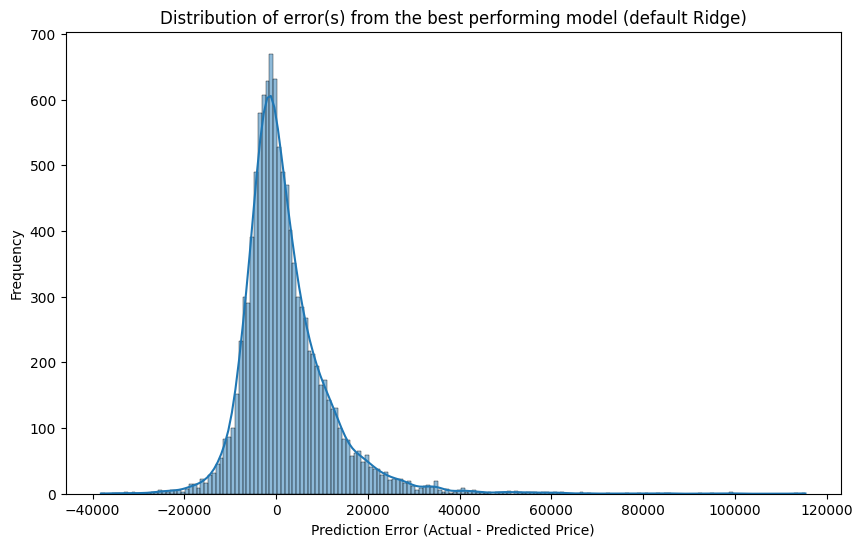

In [ ]:
 # Plot the error distribution for the best model (Ridge)
plt.figure(figsize=(10, 6))
sns.histplot(y_test_actual - y_preds_ridge_actual, kde=True)
plt.title("Distribution of error(s) from the best performing model (default Ridge)")
plt.xlabel("Prediction Error (Actual - Predicted Price)")
plt.ylabel("Frequency")
plt.show()
# we get a 0 mean centered normal distribution which aligns with our understanding.


Considering that we have a normalized mean of errors , we can treat our model as final and comprehend the
coefficient values of the features to make meaningful insights for final report to car dealers .

In [ ]:
# sort by absolute values and display the coefs against the transformed features
pd.set_option('display.max_rows', None)
display(_coefs.sort_values(ascending=False))
pd.reset_option('display.max_rows')

,0
categorical_transformer__manufacturer_ferrari,1.482656
categorical_transformer__manufacturer_datsun,0.869638
categorical_transformer__condition_new,0.496652
categorical_transformer__manufacturer_porsche,0.495268
categorical_transformer__manufacturer_aston-martin,0.401551
categorical_transformer__manufacturer_tesla,0.331500
frequency_transformer__0,0.330008
categorical_transformer__paint_color_orange,0.173960
categorical_transformer__transmission_other,0.151186
categorical_transformer__condition_like new,0.144190


### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

From the above table (unique counts and nulls for each feature), we can infer correctly that the following categories of feature were dropped while doing ohe .
Dropped categories for OneHotEncoded features:
 manufacturer: acura

 fuel: diesel

 title_status: clean

 transmission: automatic

 drive: 4wd

 paint_color: black

 state: ak

 cylinders: 10

 condition: excellent

Along with the above , following considerations need to be understood for interpretation-

1.The target value (price) was natural-log transformed , though RMSE and R2_scores were all based on actual predicted values after exponentiation.

2. Hence, when interpreting coefficients for our final model (log(price)= beta0+ sigma(beta(i)*x(i)))

  a. For numerical features - one unit change would result in %age change (+ve or -ve) on the price value , keeping other features unchanged .

  b. For categorical feature - the presence of the dummy category value would mean, keeping everything unchanged would cause that much %age increase or decrease in price as indicated by the coeffs .

  c. For 'car model' (feature encoded), keeping it simple - a particular model would cause the price to go +/- slightly as per the coeff sign .

  d.A positive coefficient means that, holding all else constant, observations in that category have a higher expected price than the reference category; a negative coefficient means a lower expected price.

3. %age change for 1 unit change in value is defined as
(np.exp(coeff_value)-1 ) *100 guided by the sign for direction of impact (incr/decr).
For smaller coeffs (abs(coeff_val)< 0.2, we would directly take the coeff_val as approx %age increase or decrease)

4. For dropped category features, the %age change is relative to the referenced category as defined at the start of the cell.


<!--
Dropped categories for OneHotEncoded features:
  manufacturer: acura
  fuel: diesel
  title_status: clean
  transmission: automatic
  drive: 4wd
  paint_color: black
  state: ak
  cylinders: 10
  condition: excellent -->

In [ ]:
# What features make a car more or less expensive.
# Provide clear recommedations to used car dealers about what customers value in a used car
# From existing experience , you can tailor your findings towards manufacturer's dealerships and private individual car dealers distinctively .
# Due to ohe, the numeber of dummies have  exploded making the feature set quite expansive .
# Hence, we will focusing only on the major drivers of car price and major detractors meaning shrinking the price and others can be similarly interpreted.

In [ ]:
# Prepared excel and pasted the table below.

In [ ]:
observations = pd.read_csv("/content/sample_data/PracticalAssignment2_feature_interpret.csv")
observations

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,Feature,Coefficient Value,Impact,Interpretation
1,manufacturer_datsun,0.79214,Strong positive,This looks like an anomaly or a rare / old bra...
2,manufacturer_ferrari,0.777547,Strong positive,"Keeping all other features unchanged, ferari m..."
3,frequency_transformer__model,0.455596,Strong positive,np.exp(0.455480) = 1.577-1 = 0.577\nThis corre...
4,anufacturer_aston-martin,0.373528,Strong positive,Luxury brand
5,condition_new,0.297147,Significant Positive,Well maintained in good condition depreceates ...
6,cylinders_12,0.294719,Significant Positive,Powerful engine would cause price to be higher...
7,manufacturer_porsche,0.231962,Positive,Luxury brand
8,numeric_transformer__age,-0.224114,Negative,"approx 22% decrease for each year old , age of..."
9,fuel_gas,-0.244229,Negative,Quite negative compared to reference category ...


**Primary findings and actionable insights**




**Top Drivers of positive influence (Highest Impact):**

Brand/Manufacturer (luxury brands command a premium, while others might be discounted), whereas some vintage brands also demand a premium .

Condition (especially poor condition severely lowers price)

and the Specific Model (capturing popularity, features, and overall desirability) needs to be combined in Make/Model to have any measurable impact on prices .

**Significant Depreciators**: High Age and high Odometer readings consistently lead to lower prices.

Risk Factors: Problematic Title Status (salvage, parts only, lien) are major red flags that drastically reduce value due their unreliability

Hence , a dealer should prioritize acquiring and maintaining cars which are
1. good to excellent condition

2. Stock pile the inventory for specific manufacturers and models by understand the market demand for specific models

3. Age causes depreciation and hence should be considered before a dealer considers trade-in or part-exchange with used car sellers.

4. mileage- Odometer does play a role as it signals internal deterioration of engine , chassis and mechanical parts which are not visible to naked eye. Its like the "life" of the car and hence causes depreciation. A car dealer should consider stocking low mileage cars more .

5. There is quite a significant impact of state specific behavior hence a local dealer should be aware of state-specific pricing trends for accurate valuation.Local supply demand cannot be interpreted directly from national averages .

6.Minor Factors such as Fuel_type, number of cylinders, transmission type, drive type, and even paint color have smaller, but still measurable, effects on price.

7. Manual cars still are more popular than automatic and so are fuel based cars compared to hybrid and electrics .

8. All wheel drive cars should be priced more than 2 wheel drives as a general rule of thumb .

**SHAP Summary Plot Plot the shap summary for feature interpretability and importance**

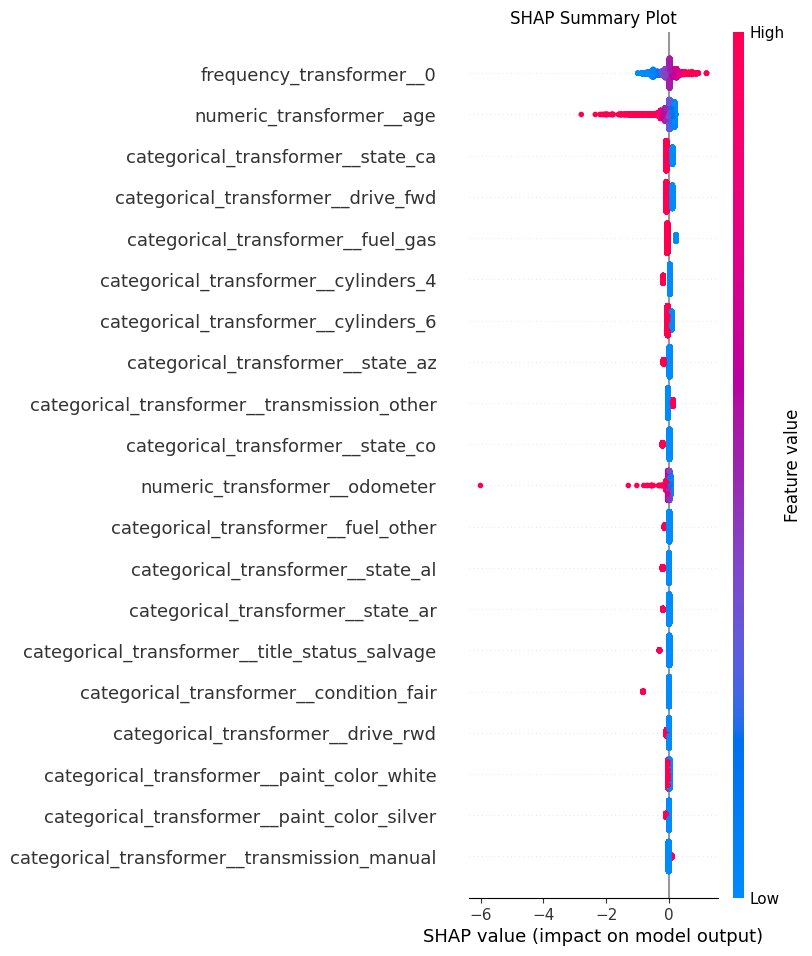

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.sparse import issparse

# Ensure the pipeline is fitted
ridge_pipeline.fit(X_train, y_train)

# Transform data
X_test_processed = ridge_pipeline.named_steps['preprocesor'].transform(X_test)
X_train_processed = ridge_pipeline.named_steps['preprocesor'].transform(X_train)

# Convert to dense if sparse to fix the DataFrame shape mismatch
if issparse(X_test_processed):
    X_test_processed = X_test_processed.toarray()
if issparse(X_train_processed):
    X_train_processed = X_train_processed.toarray()

# Get feature names
feature_names_processed = ridge_pipeline.named_steps['preprocesor'].get_feature_names_out()

# Create DataFrame for SHAP
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names_processed, index=X_test.index)

# Use LinearExplainer
explainer = shap.LinearExplainer(ridge_pipeline.named_steps['ridge_regression'], X_train_processed)
shap_values = explainer.shap_values(X_test_processed)

# Plot
shap.summary_plot(shap_values, X_test_processed_df, show=False)
plt.title("SHAP Summary Plot")
plt.show()

Ignoring the warning regarding subsampling that just indicates that SHAP used 100 samples from the training set to calculate the 'background' distribution for performance reasons.



**SHAP explanations**
This provides a visual explanation of how different features impact the car price predictions. As seen in the plot:

*Age and Odometer*: Higher values for these features (shown in red) significantly pull the price down, which aligns with typical vehicle depreciation.

*Model Importance*: The frequency_transformer__0 (representing the encoded vehicle model) shows a wide spread of impact, meaning specific models are strong drivers for both higher and lower prices.

*Categorical Drivers*: Features like fuel_gas, drive_fwd, and various state indicators also show clear directional impacts on the final valuation.

**Limitations and Future improvements or suggestions**

**Generalization to new makes** When new car brands and models come out , there wouldnt be enough data to make accurate predictions as there would be many unknowns in the existing features.

**Seasonal sales** Car sales is also heavily impacted by seasonal variations including festivals and occassions such as year end when demand is high due to holiday season, hence the algo has to evolve to consider time series data for dealers to price vehicles in order to make more profits .

**Exogenous factors** Such as current war is not considered as they can push the car price of hybrid and electric cars due to shortage of diesel or petrol-only cars due to fuel shortage temporarily .

**Manufacturing warranty**- Customers increasingly value existing warranty offered by original manufacturer which normally lasts for 3 years and hence in spite of a general assumption that car depreciates heavily in the first 3 years , this is an important factor to consider as desirability of customers would be high for buying such cars.

**Running Costs(Maintenance)**- Insurance group taken into consideration for pricing vehicles because luxury cars often have higher premiums. Annual Servicing charges also are a factor with preium cars.



## Used Car Price Prediction Project

### Modeling and Performance
*   **Models Utilized**: Baseline Linear Regression, Ridge Regression, Lasso Regression, and Elastic Net were employed to predict used car prices.
*   **Data Preparation**: Features underwent preprocessing including imputation, one-hot encoding for categorical variables, and frequency encoding for high-cardinality features like `model`.
*   **Hyperparameter Tuning**: GridSearchCV was applied to Ridge, Lasso, and Elastic Net models to optimize their regularization parameters, although default Ridge performed competitively.
*   **Best Model**: Ridge Regression (with `alpha=1` or `alpha=0.1`) demonstrated the best performance among the tested models.
*   **Performance Metrics**: The best model achieved an R2 score of approximately 0.65-0.66, indicating it explains about 65-66% of the variance in car prices, with a Root Mean Squared Error (RMSE) of around $8,300 on actual predicted prices.

### Conclusions
*   The analysis successfully established a significant relationship between various car features and the logarithmic used car price (`log_price`).
*   The Ridge Regression model provides a robust and interpretable framework for predicting used car prices.
*   The error distribution of the best model is centered around zero, suggesting unbiased predictions.
*   The model's accuracy, with an RMSE of approximately $8,300 against car prices up to $120,000, is considered reasonable for this domain.
*   The coefficients from the final model offer clear insights into the direction and magnitude of feature impacts on car price.

#### Interesting Findings
*   As observed from the `observations` data, certain manufacturers like 'datsun' and 'ferrari' show exceptionally strong positive coefficients, suggesting they command a significant premium, possibly due to rarity or luxury status.
*   The car's `model`, when frequency encoded, has a strong positive impact, highlighting the importance of specific models in pricing.
*   Car `condition` plays a crucial role; `condition_new` and `cylinders_12` (from the `cylinders` feature in `observations`) positively influence price, whereas `condition_salvage` and `condition_fair` drastically reduce it.
*   **Depreciating Factors**: Age (`numeric_transformer__age`) and `odometer` readings are consistent depreciators, with older cars and higher mileage leading to lower prices.
*   **Fuel Type Influence**: Different `fuel` types exhibit varying impacts, with 'gas', 'hybrid', and 'electric' showing negative coefficients relative to the reference `diesel`, indicating a preference for diesel or other unlisted fuel types in the market represented by the dataset.

### Actionable Insights
*   **Condition is Key**: Dealers should prioritize acquiring and maintaining cars in good to excellent condition, as poor conditions severely degrade value.
*   **Inventory Strategy**: Focus on stockpiling inventory for specific manufacturers and models that align with market demand, leveraging insights into highly valued brands and popular models.
*   **Age and Mileage Management**: Factor in depreciation due to age and high odometer readings when considering trade-ins or sourcing vehicles; low mileage cars generally command higher prices.
*   **Local Market Awareness**: Recognize that state-specific pricing trends are significant, and local dealers should tailor valuations based on regional supply and demand rather than national averages.
*   **Minor Feature Impacts**: While less impactful than condition or brand, factors like fuel type, number of cylinders, transmission, drive type, and paint color still contribute measurably to pricing and should not be overlooked.
*   **Consumer Preferences**: Manual and traditional fuel-based cars (like gasoline, relative to the negative coefficients for hybrid and electric) may still be more popular than automatics or alternative fuel vehicles in this market.
*   **Drivetrain Value**: All-wheel drive (AWD) cars are generally priced higher than two-wheel drive options.